# No Central Beams

Fits excluding the central beam dispersion of the CO and [CII] data cubes. Results presented in Table S6. 

In [1]:
import numpy as np
from SMBH_fitter import ModelVelocity, log_prob, MCMC, ReadData

In [2]:
#This deactivates the threading from numpy and is useful to do to make sure the threading from emcee is not affected by the threading from numpy. 
import os
os.environ["OMP_NUM_THREADS"] = "1"

## Initilizations

Here we first read the data file, using the [ReadData](readData.py) object. This is just for conveniency, but it is simply a function that reads and stores the relevant numbers in the file [data.dat](data.dat). 

The second step is to initialize the [ModelVelocity](modelVelocity.py) object, which holds a number of values relevant for the modeling and creates the interpolated values of the F and g functions. See the [README file](README.md) for more details. 

Finally, we set the boundaries for each of the parameters to be used during the MCMC. 

In [3]:
#Read the measurements. 
data = ReadData("data/data_no_central_points.dat")

In [4]:
#Initialize the modeling object. This takes some time as some functions need to be interpolated. 
modelv = ModelVelocity(data)

## Preferred Model

This calculation represents the main result of the paper, and produces the outputs that generate Figures 2 and S18.

In [ ]:
#Set the bounds for each of the parameters we will fit. 

#SMBH Mass
log_Mbh_min  , log_Mbh_max   = 0.0 , 11.0 #Base 10 logarithm of the SMBH mass in units of Solar Masses.

#Host Galaxy Parameters
n_host_min , n_host_max      = 0.50,  2.01 #Sersic index 
Re_host_min, Re_host_max     = 1.1 ,  1.6 #Effective radius in kpc. 
log_Mhost_min, log_Mhost_max = 8.0 , 12.0 #Base 10 logarithm of the total host mass in units of Solar Masses.

#Put the bounds in the right format and order for the MCMC. 
params_min = np.array([n_host_min,  log_Mhost_min, Re_host_min, log_Mbh_min])
params_max = np.array([n_host_max,  log_Mhost_max, Re_host_max, log_Mbh_max])

In [6]:
#Initial guesses. Order is n, log Mbulge, re bulge, log Mbh.
params_init = np.array([1.5, 10.5, 1.5, 10.])

#Set which parameters are fixed. In this case, it is none, so it is just an array of False values.
ifix  = np.zeros(params_init.shape, dtype=bool)

In [7]:
#####
# MCMC
#####

#Set the MCMC object, which is just a convenient wrapper for emcee. 
myMCMC = MCMC(params_init, params_min, params_max, modelv, log_prob, data.sigma_obs, data.sigma_obs_err, ifix=ifix)

#Run th MCMC
myMCMC.runMCMC()

#Save the flatchain. 
myMCMC.save_flat_samples("MCMC_flatchain.all_params.no_central_beams.constrained_sersic.txt")
#myMCMC.load_flat_samples("CMC_flatchain.all_params.no_central_beams.constrained_sersic.txt")

100%|██████████| 5000/5000 [09:13<00:00,  9.03it/s]


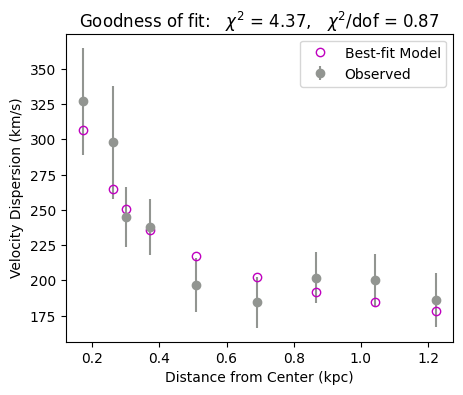

In [8]:
#Plot the best-fit model compared to the data. 
myMCMC.plot_bestfit()

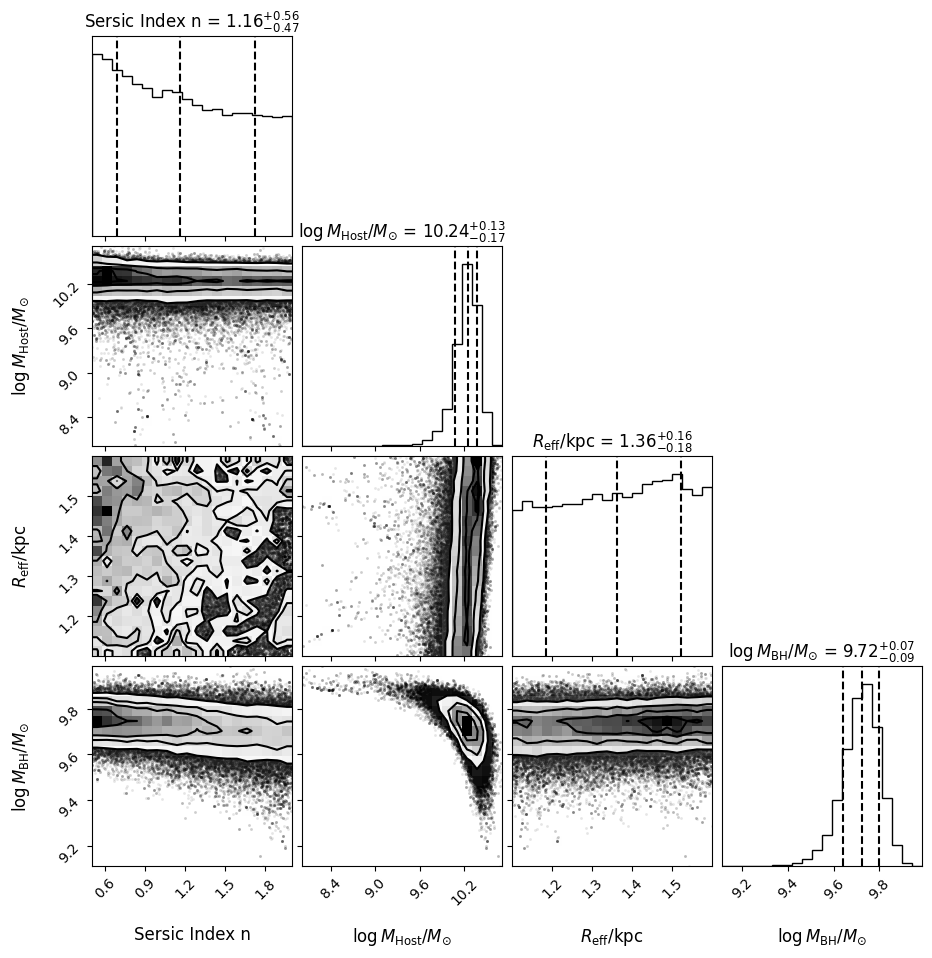

In [9]:
#Make the corner plot.
myMCMC.corner_plot()

# Single Sersic

In [5]:
#Set the bounds for each of the parameters we will fit. 

#SMBH Mass
log_Mbh_min  , log_Mbh_max   = 0.0 , 11.0 #Base 10 logarithm of the SMBH mass in units of Solar Masses.

#Host Galaxy Parameters
n_host_min , n_host_max      = 0.45, 10.0 #Sersic index 
Re_host_min, Re_host_max     = 0.50, 10.0 #Effective radius in kpc. 
log_Mhost_min, log_Mhost_max = 8.0 , 12.0 #Base 10 logarithm of the total host mass in units of Solar Masses.

#Put the bounds in the right format and order for the MCMC. 
params_min = np.array([n_host_min,  log_Mhost_min, Re_host_min, log_Mbh_min])
params_max = np.array([n_host_max,  log_Mhost_max, Re_host_max, log_Mbh_max])

In [6]:
#Initial guesses. Order is n, log Mbulge, re bulge, log Mbh.
params_init = np.array([1.5, 10.5, 1.5, 0.])

#Set which parameters are fixed. In this case, it is none, so it is just an array of False values.
ifix  = np.zeros(params_init.shape, dtype=bool)
ifix[-1] = True

In [7]:
#####
# MCMC
#####

#Set the MCMC object, which is just a convenient wrapper for emcee. 
myMCMC = MCMC(params_init, params_min, params_max, modelv, log_prob, data.sigma_obs, data.sigma_obs_err, ifix=ifix)

#Run th MCMC
myMCMC.runMCMC()

#Save the flatchain. 
myMCMC.save_flat_samples("MCMC_flatchain.no_SMBH.no_central_beams.constrained_sersic.txt")
#myMCMC.load_flat_samples("CMC_flatchain.no_SMBH.no_central_beams.constrained_sersic.txt")

100%|██████████| 5000/5000 [15:10<00:00,  5.49it/s]


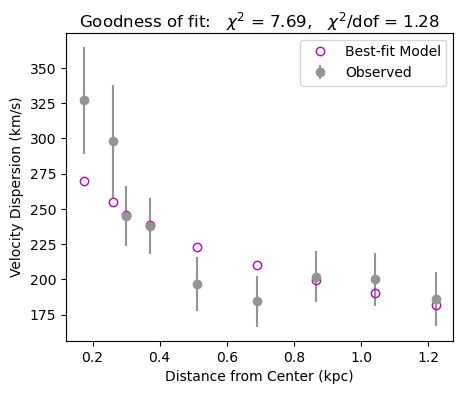

In [8]:
#Plot the best-fit model compared to the data. 
myMCMC.plot_bestfit()

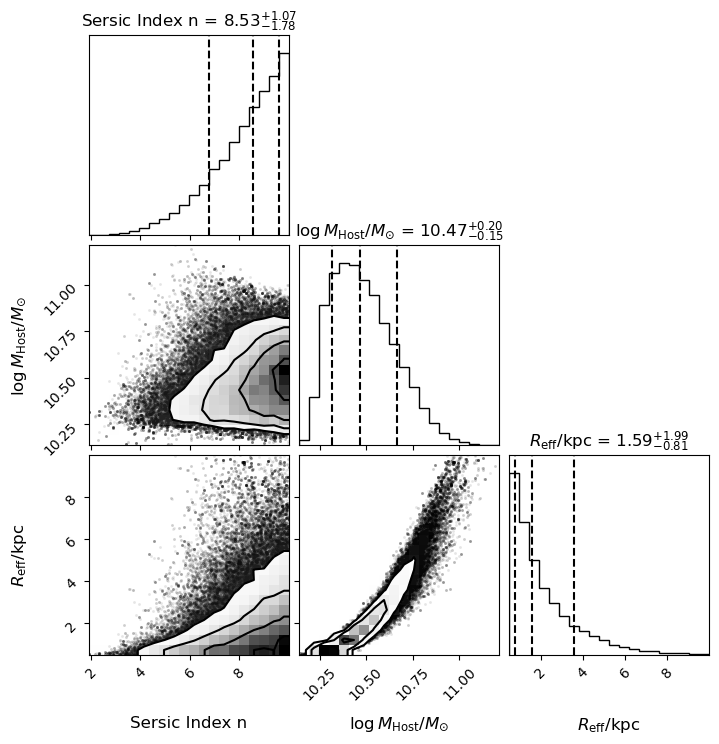

In [9]:
#Make the corner plot.
myMCMC.corner_plot()